# 05 · Reclassifying the VUS

The 341 VUS were never used for training or tuning. Each saved pipeline returns **P(Pathogenic)**; the final call is a **majority vote** of the three model calls, and the **ensemble probability** is the mean of the three.

**Confidence tiers** (ensemble probability): High if P ≥ 0.80 or P ≤ 0.10; Medium if 0.60 ≤ P < 0.80 or 0.10 < P ≤ 0.25; Low otherwise. Low-confidence calls should be reviewed first.

> These calls are decision support for expert variant curation, not a substitute for ACMG/AMP classification.

In [1]:
# --- Setup: make the project package importable from notebooks/ -------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

from src import config as cfg
print("Project root:", ROOT)

Project root: /home/claude/vus-reclassification


In [2]:
# Make sure the processed splits exist (runs the data stage if needed).
from src.data import make_dataset
if not cfg.TRAIN_FILE.exists():
    make_dataset.main()

In [3]:
from src.models import predict_model as pm
from src.models.train_model import load_models
from src.data.make_dataset import load_split

if not all(p.exists() for p in cfg.MODEL_FILES.values()):
    from src.data import make_dataset; from src.features import build_features as bf
    from src.models import train_model as tm
    make_dataset.main(); bf.run(); tm.run(); plt.close("all")

models, meta = load_models()
vus = load_split("vus")
print(vus.shape)
vus[meta["features"]].head()

(341, 30)


,REVEL_Score,PolyPhen2_Score,gnomAD_AF,CADD_Phred,GERP_RS,HRD_Score,SIFT_Score,PhyloP_100way,SpliceAI_Score,Tumor_Mutational_Burden,Variant_Allele_Freq,Age,Ki67_Index,Variant_Type,In_Functional_Domain,Family_History_Cancer
0,0.901,1.000,5.870000e-06,45.04,3.22,39.7,NaN,-8.76,0.000,0.00,0.020,74.0,22.3,NaN,Yes,Yes
1,0.513,0.987,7.229590e-03,0.00,3.97,39.8,0.000,5.30,0.877,15.02,0.673,48.0,31.1,Synonymous,Yes,NaN
2,0.626,0.446,1.025770e-02,NaN,-3.59,49.1,0.166,-2.97,0.000,0.00,0.020,66.0,30.2,Synonymous,No,No
3,NaN,0.574,5.618800e-04,0.19,-3.80,89.8,NaN,2.51,0.000,NaN,0.362,69.0,NaN,Missense,No,Yes
4,0.192,0.000,1.000000e-07,24.62,4.16,0.0,1.000,-2.40,0.500,3.51,0.259,NaN,11.4,Missense,No,Yes


In [4]:
res = pm.reclassify(vus, models, meta)
res.head(10)

,Variant_ID,P_Pathogenic_XGBoost,Call_XGBoost,P_Pathogenic_SVM_RBF,Call_SVM_RBF,P_Pathogenic_Transformer,Call_Transformer,P_Pathogenic_Ensemble,P_Benign_Ensemble,Reclassified_As,Model_Agreement,Confidence
0,VAR00007,0.4293,Pathogenic,0.4490,Pathogenic,0.7861,Pathogenic,0.5548,0.4452,Pathogenic,3/3,Low
1,VAR00015,0.3783,Pathogenic,0.5545,Pathogenic,0.6943,Pathogenic,0.5424,0.4576,Pathogenic,3/3,Low
2,VAR00025,0.0120,Benign,0.0167,Benign,0.0217,Benign,0.0168,0.9832,Benign,3/3,High
3,VAR00031,0.0535,Benign,0.0551,Benign,0.0247,Benign,0.0444,0.9556,Benign,3/3,High
4,VAR00035,0.0460,Benign,0.0348,Benign,0.0230,Benign,0.0346,0.9654,Benign,3/3,High
5,VAR00038,0.8924,Pathogenic,0.7350,Pathogenic,0.8012,Pathogenic,0.8095,0.1905,Pathogenic,3/3,High
6,VAR00049,0.0748,Benign,0.1040,Benign,0.0275,Benign,0.0688,0.9312,Benign,3/3,High
7,VAR00050,0.6006,Pathogenic,0.5627,Pathogenic,0.7586,Pathogenic,0.6406,0.3594,Pathogenic,3/3,Medium
8,VAR00075,0.0388,Benign,0.0606,Benign,0.0296,Benign,0.0430,0.9570,Benign,3/3,High
9,VAR00088,0.0696,Benign,0.1033,Benign,0.0699,Benign,0.0809,0.9191,Benign,3/3,High


In [5]:
summary = pd.crosstab(res["Reclassified_As"], res["Confidence"], margins=True)
summary

Confidence,High,Low,Medium,All
Reclassified_As,,,,
Benign,152,1,38,191
Pathogenic,11,85,54,150
All,163,86,92,341


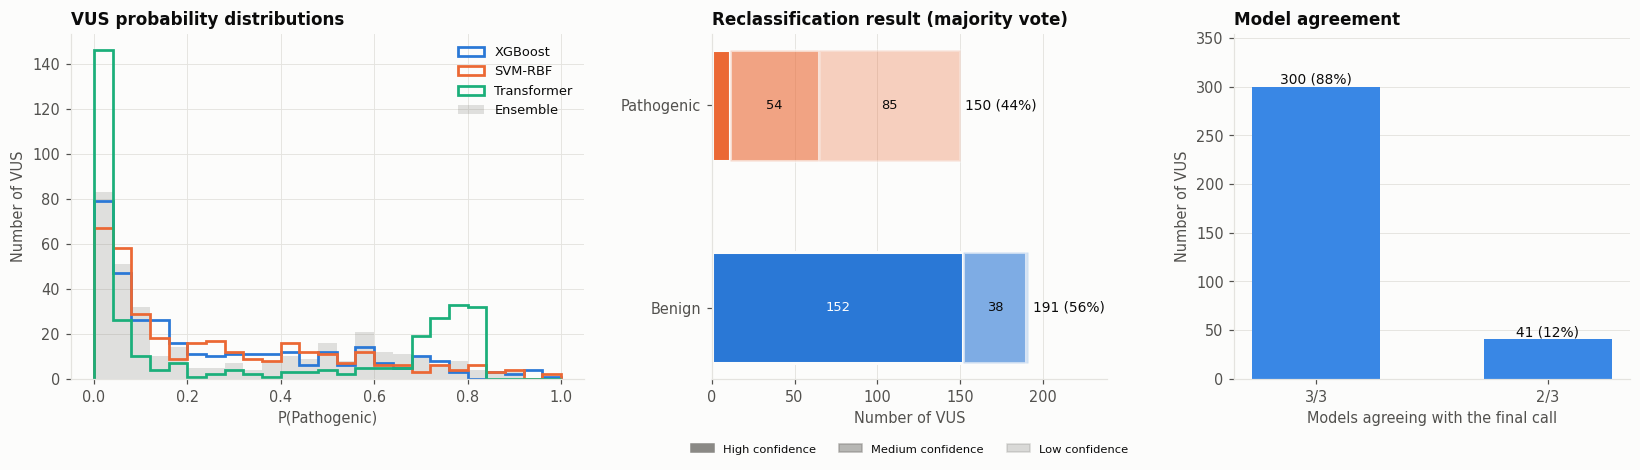

In [6]:
pm.plot_vus(res);

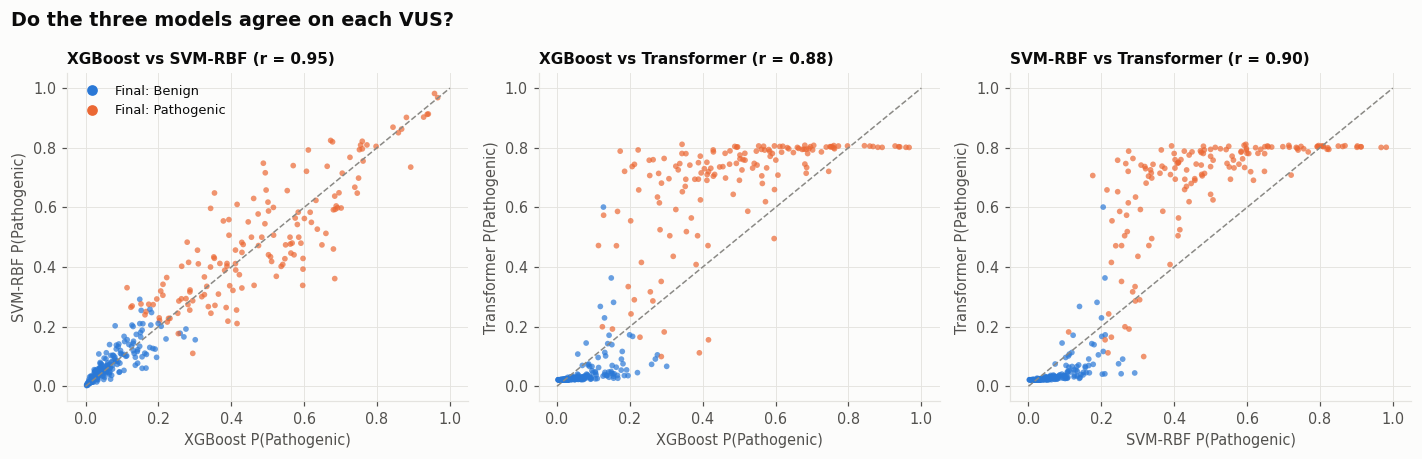

In [7]:
pm.plot_vus_pairwise(res);

## Which VUS need expert review first?
Variants where the models disagree (2/3) or the ensemble probability is closest to the boundary.

In [8]:
review = res[(res.Model_Agreement == "2/3") | (res.Confidence == "Low")] \
          .assign(dist=lambda d: (d.P_Pathogenic_Ensemble - 0.5).abs()).sort_values("dist")
print(f"{len(review)} of {len(res)} VUS flagged for priority review")
review.drop(columns="dist").head(10)

113 of 341 VUS flagged for priority review


,Variant_ID,P_Pathogenic_XGBoost,Call_XGBoost,P_Pathogenic_SVM_RBF,Call_SVM_RBF,P_Pathogenic_Transformer,Call_Transformer,P_Pathogenic_Ensemble,P_Benign_Ensemble,Reclassified_As,Model_Agreement,Confidence
322,VAR03224,0.4626,Pathogenic,0.3385,Pathogenic,0.6984,Pathogenic,0.4998,0.5002,Pathogenic,3/3,Low
272,VAR02740,0.4122,Pathogenic,0.3899,Pathogenic,0.7100,Pathogenic,0.5040,0.4960,Pathogenic,3/3,Low
270,VAR02716,0.3881,Pathogenic,0.4030,Pathogenic,0.6945,Pathogenic,0.4952,0.5048,Pathogenic,3/3,Low
84,VAR00850,0.5236,Pathogenic,0.3688,Pathogenic,0.5870,Pathogenic,0.4931,0.5069,Pathogenic,3/3,Low
97,VAR00953,0.3535,Pathogenic,0.4292,Pathogenic,0.6942,Pathogenic,0.4923,0.5077,Pathogenic,3/3,Low
274,VAR02748,0.2790,Pathogenic,0.4833,Pathogenic,0.7139,Pathogenic,0.4921,0.5079,Pathogenic,3/3,Low
70,VAR00700,0.3430,Pathogenic,0.4000,Pathogenic,0.7807,Pathogenic,0.5079,0.4921,Pathogenic,3/3,Low
328,VAR03272,0.3937,Pathogenic,0.5066,Pathogenic,0.6251,Pathogenic,0.5085,0.4915,Pathogenic,3/3,Low
189,VAR01764,0.4222,Pathogenic,0.3742,Pathogenic,0.7311,Pathogenic,0.5091,0.4909,Pathogenic,3/3,Low
71,VAR00712,0.4291,Pathogenic,0.3296,Pathogenic,0.7046,Pathogenic,0.4878,0.5122,Pathogenic,3/3,Low


## Most confident reclassifications

In [9]:
cols = ["Variant_ID", "P_Pathogenic_Ensemble", "Reclassified_As", "Model_Agreement", "Confidence"]
display(res.sort_values("P_Pathogenic_Ensemble", ascending=False)[cols].head(5))
display(res.sort_values("P_Pathogenic_Ensemble")[cols].head(5))

,Variant_ID,P_Pathogenic_Ensemble,Reclassified_As,Model_Agreement,Confidence
137,VAR01348,0.9137,Pathogenic,3/3,High
143,VAR01425,0.9118,Pathogenic,3/3,High
196,VAR01842,0.8856,Pathogenic,3/3,High
290,VAR02897,0.8844,Pathogenic,3/3,High
256,VAR02595,0.8788,Pathogenic,3/3,High


,Variant_ID,P_Pathogenic_Ensemble,Reclassified_As,Model_Agreement,Confidence
140,VAR01384,0.0091,Benign,3/3,High
174,VAR01641,0.0097,Benign,3/3,High
213,VAR02102,0.0101,Benign,3/3,High
22,VAR00208,0.0106,Benign,3/3,High
100,VAR00978,0.0109,Benign,3/3,High


## Score new variants in production
The same function scores any CSV with the raw variant columns. From the command line: `python -m src.models.predict_model --input new.csv --output predictions.csv`

In [10]:
new = vus.sample(3, random_state=0)        # stand-in for newly sequenced variants
pm.reclassify(new, models, meta)[cols]

,Variant_ID,P_Pathogenic_Ensemble,Reclassified_As,Model_Agreement,Confidence
0,VAR00745,0.1125,Benign,3/3,Medium
1,VAR00986,0.7363,Pathogenic,3/3,Medium
2,VAR00544,0.7891,Pathogenic,3/3,Medium


In [11]:
# Save the full output (reports/vus_reclassification.csv) and figures, as `make predict` does
_ = pm.main(); plt.close("all")

16:34:27 | INFO    | src.models.predict_model | Reclassified 341 variants: {'Benign': 191, 'Pathogenic': 150} -> /home/claude/vus-reclassification/reports/vus_reclassification.csv
